In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [12]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 9
NDATASETS = 4  # ajuste se houver mais datasets

In [13]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [14]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [15]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.034    Raio da roda (m)
- L = 0.147/2  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [16]:
R = 0.032   
L = 0.124  
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [17]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [18]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_24_5,24,[0.9224542937325335],[0.28972593875866953],[0.9522683170310767],[0.20310628325065708],[0.9388101726903245],[0.3185980571000879],[0.9425440829222376],[0.20654530678809518],[0.9555653867466339],[0.1879401204323284],[0.9170073726458436],[0.4429100824148256],"[[[0.08699999749660492, 0.11980000138282776, 0...","[[[0.1559000015258789, -0.05169999971985817, -..."
1,model_12_4,12,[0.9158692604108013],[0.31432891231745724],[0.9524359221658105],[0.2023930954087013],[0.9244556035200195],[0.39333822305974603],[0.9380703961538781],[0.22262753213651398],[0.9498924363049935],[0.2119343652596479],[0.9134577898647187],[0.4618532831815327],"[[[-0.003000000026077032, 0.06040000170469284,...","[[[0.21330000460147858, 0.15199999511241913, 0..."
2,model_22_0,22,[0.9229401291455087],[0.2879107625499323],[0.9483643138276329],[0.21971846893383076],[0.9378662940446554],[0.3235125652114862],[0.9445889195183237],[0.1991944293928479],[0.9496324046244012],[0.2130341922141008],[0.9100690713594644],[0.47993799311652496],"[[[-0.09109999984502792, -0.0949999988079071, ...","[[[-0.07129999995231628, 0.16670000553131104, ..."
3,model_25_3,25,[0.9175043960827184],[0.30821972535731834],[0.9491569642507999],[0.21634560899358277],[0.9193505331746018],[0.4199188748595627],[0.9462209847761702],[0.19332740234802873],[0.9502607537824097],[0.21037653396564698],[0.9079198808164117],[0.4914076644704216],"[[[0.004000000189989805, -0.01979999989271164,...","[[[0.059300001710653305, 0.011300000362098217,..."




===== Avaliando Dataset 1 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_24_5 =====
R2_X = 0.9414, MSE_X = 0.005924
R2_Y = -3.2461, MSE_Y = 0.338235
R2_Theta = -0.0841, MSE_Theta = 0.304537


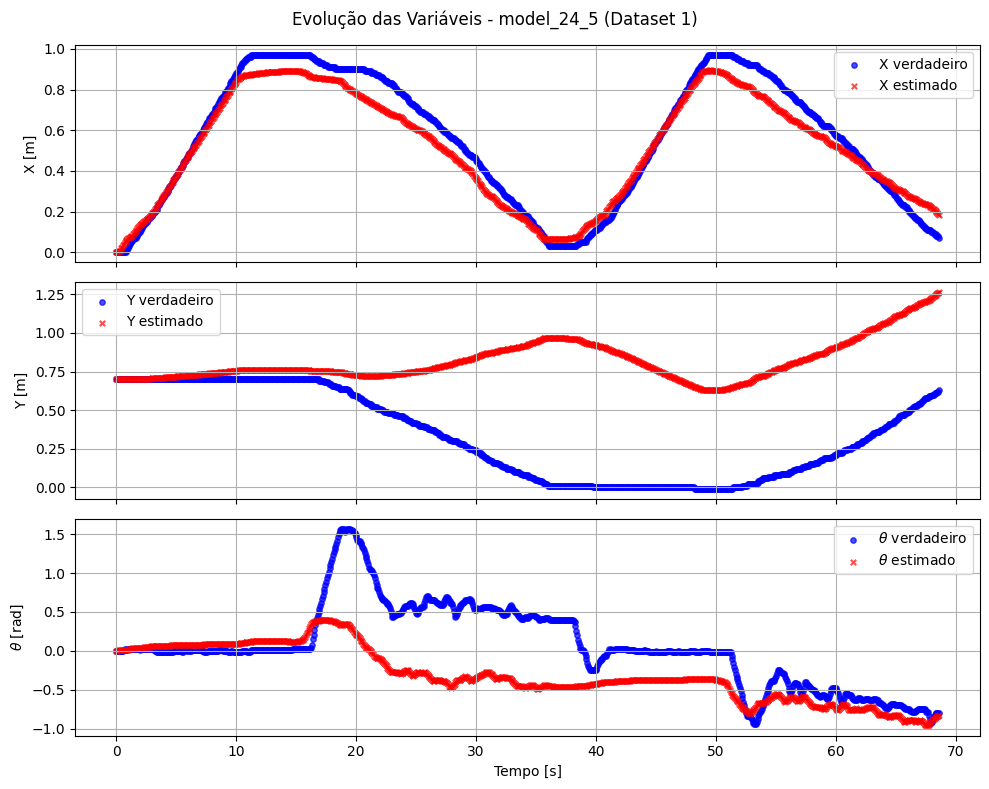

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_12_4 =====
R2_X = -0.7989, MSE_X = 0.181917
R2_Y = -36.5575, MSE_Y = 2.991757
R2_Theta = -60.0690, MSE_Theta = 17.155139


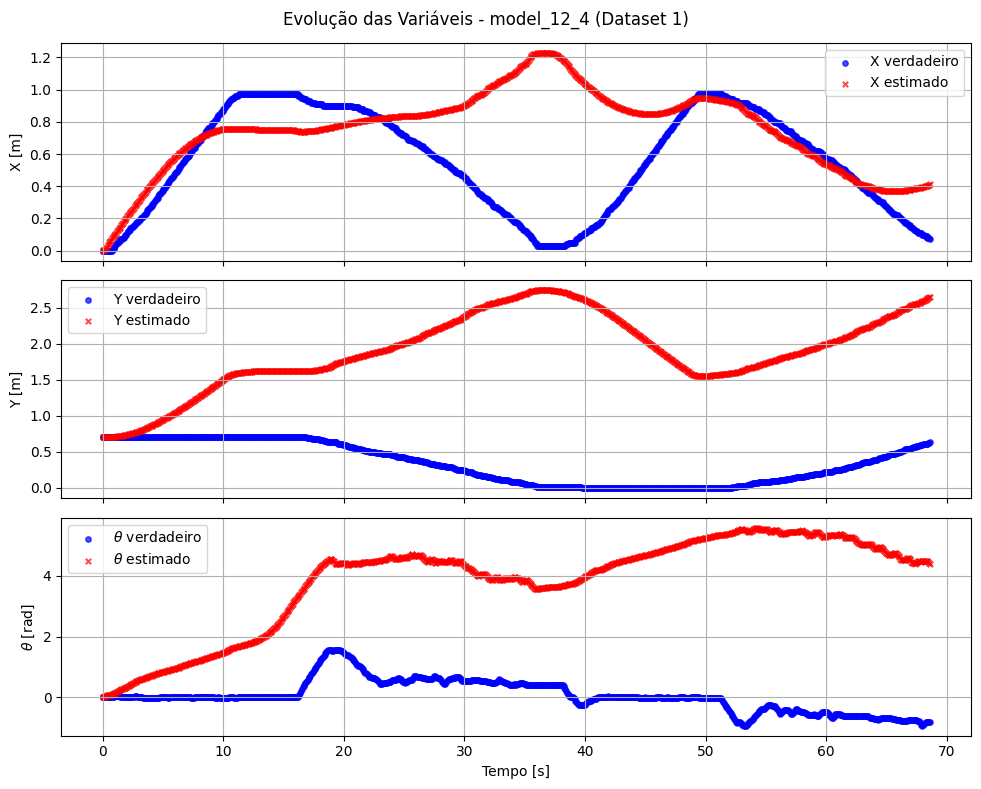

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_22_0 =====
R2_X = -1.2597, MSE_X = 0.228513
R2_Y = -0.5244, MSE_Y = 0.121430
R2_Theta = -409.4644, MSE_Theta = 115.305155


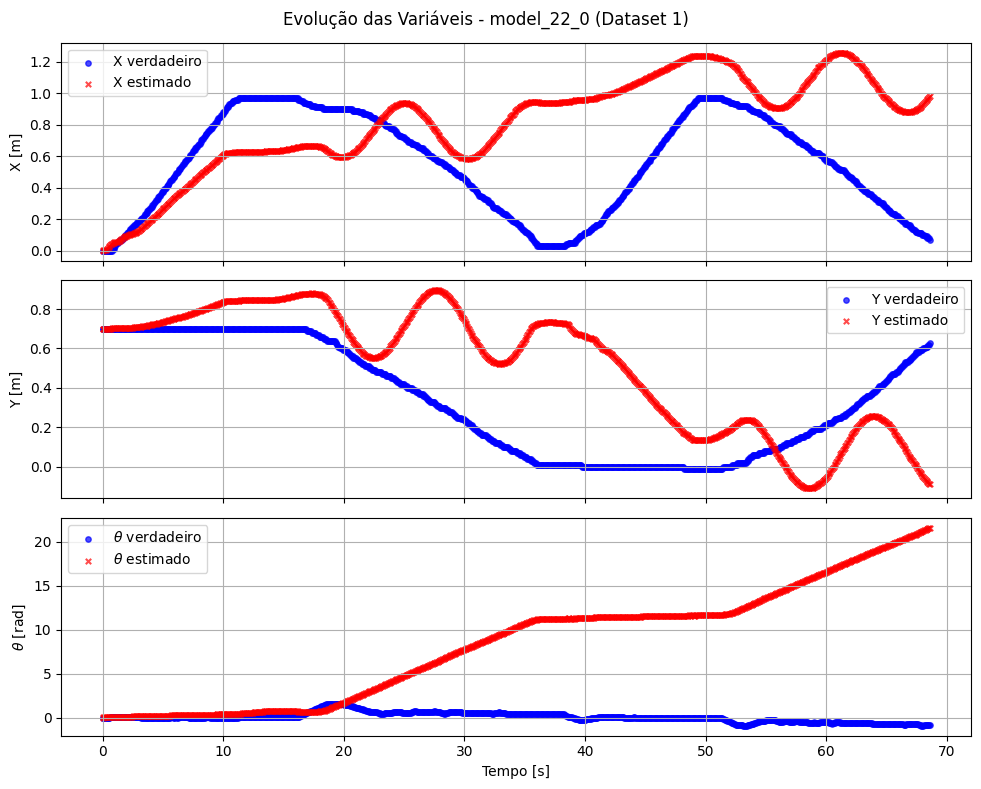

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_25_3 =====
R2_X = 0.7980, MSE_X = 0.020429
R2_Y = -3.8857, MSE_Y = 0.389184
R2_Theta = -1.2180, MSE_Theta = 0.623066


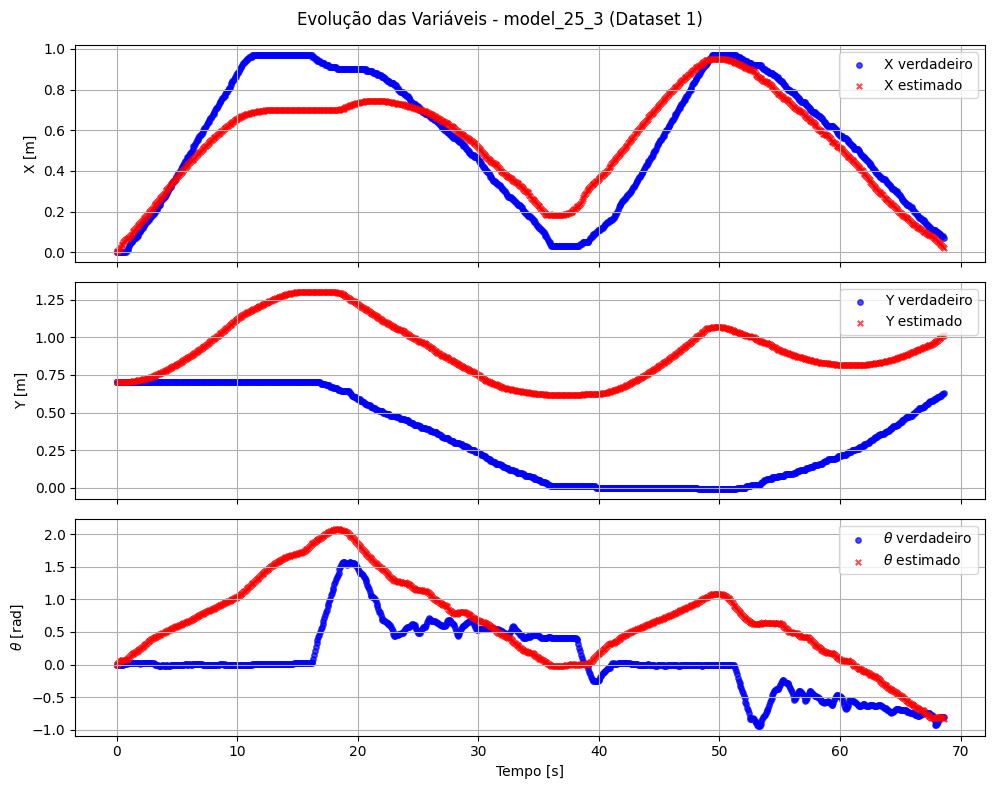



===== Avaliando Dataset 2 =====
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_24_5 =====
R2_X = -10.4360, MSE_X = 1.062249
R2_Y = -12.1681, MSE_Y = 0.688233
R2_Theta = -0.5536, MSE_Theta = 4.578568


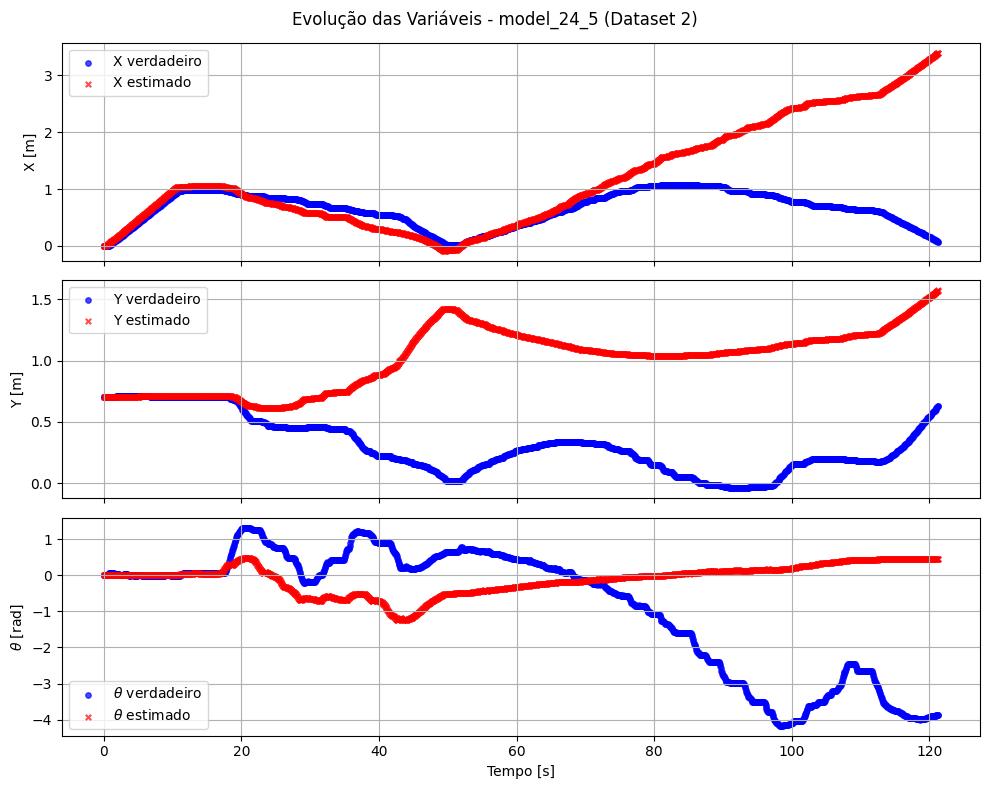

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_12_4 =====
R2_X = -31.3505, MSE_X = 3.004915
R2_Y = -41.0526, MSE_Y = 2.197892
R2_Theta = -23.9571, MSE_Theta = 73.549491


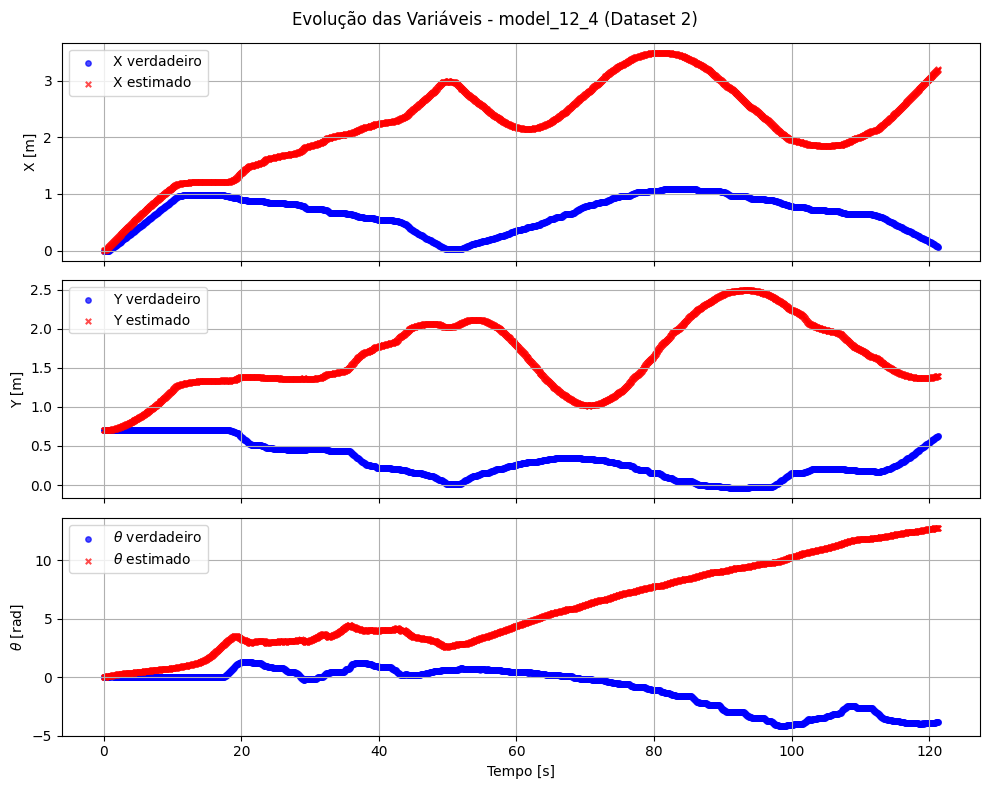

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== model_22_0 =====
R2_X = -5.4419, MSE_X = 0.598363
R2_Y = -3.2595, MSE_Y = 0.222624
R2_Theta = -72.9542, MSE_Theta = 217.945225


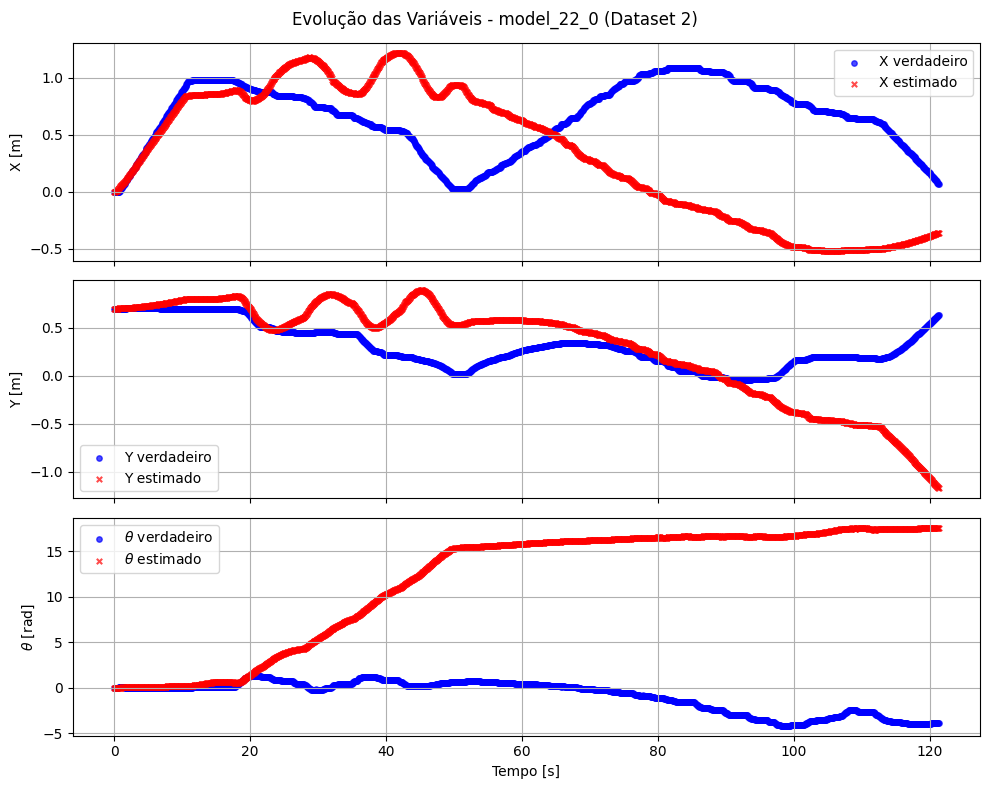

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_25_3 =====
R2_X = -7.4684, MSE_X = 0.786601
R2_Y = -31.1867, MSE_Y = 1.682249
R2_Theta = -5.3550, MSE_Theta = 18.728481


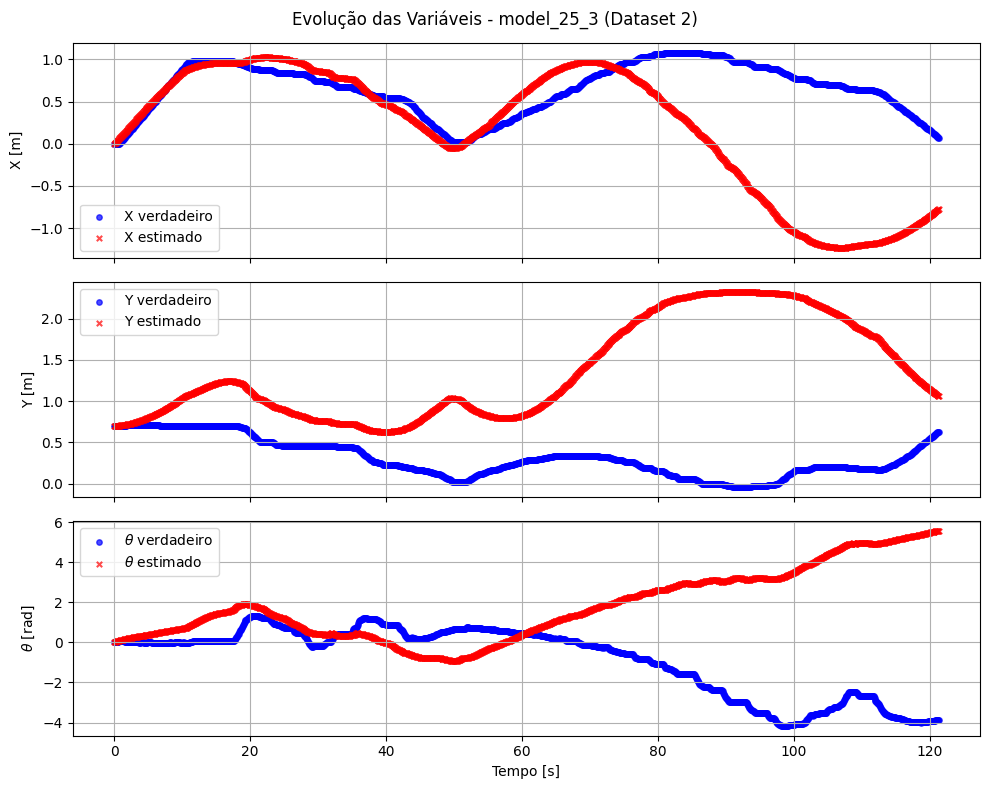



===== Avaliando Dataset 3 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_24_5 =====
R2_X = -1.0277, MSE_X = 0.160334
R2_Y = -8.4821, MSE_Y = 0.562015
R2_Theta = -8.8709, MSE_Theta = 3.927026


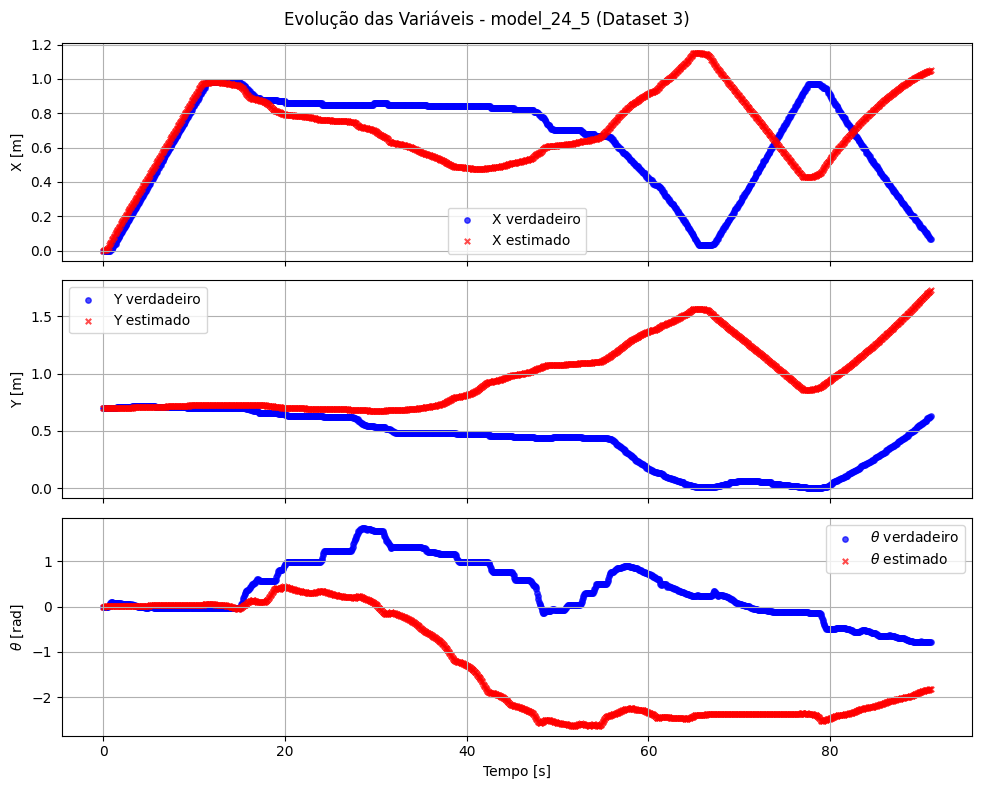

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_12_4 =====
R2_X = 0.0947, MSE_X = 0.071585
R2_Y = -17.7656, MSE_Y = 1.112266
R2_Theta = -61.0185, MSE_Theta = 24.673432


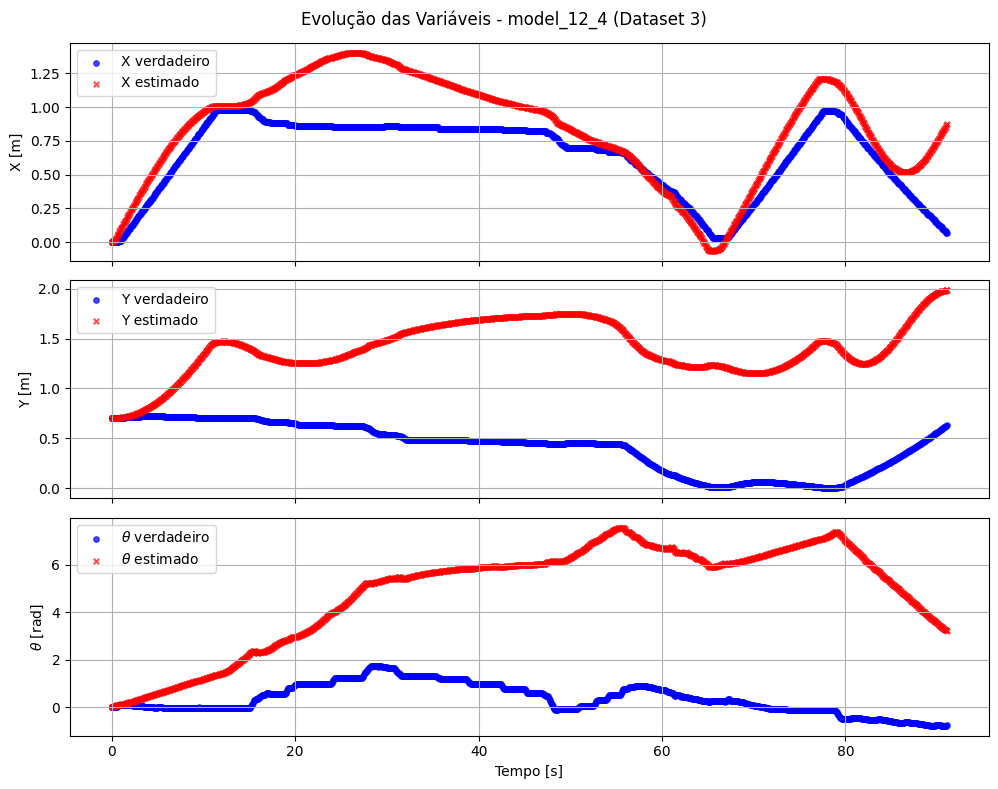

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_22_0 =====
R2_X = -0.0279, MSE_X = 0.081277
R2_Y = -0.7242, MSE_Y = 0.102195
R2_Theta = -702.4643, MSE_Theta = 279.866100


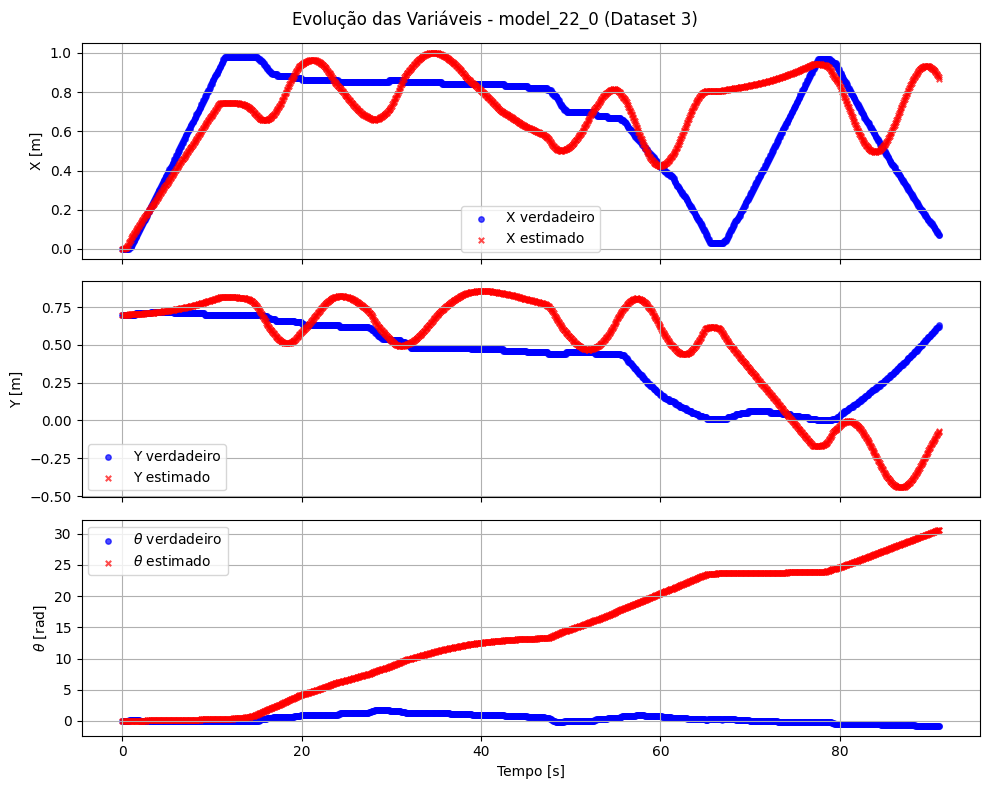

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_25_3 =====
R2_X = -0.7123, MSE_X = 0.135398
R2_Y = -8.9468, MSE_Y = 0.589561
R2_Theta = -6.3592, MSE_Theta = 2.927781


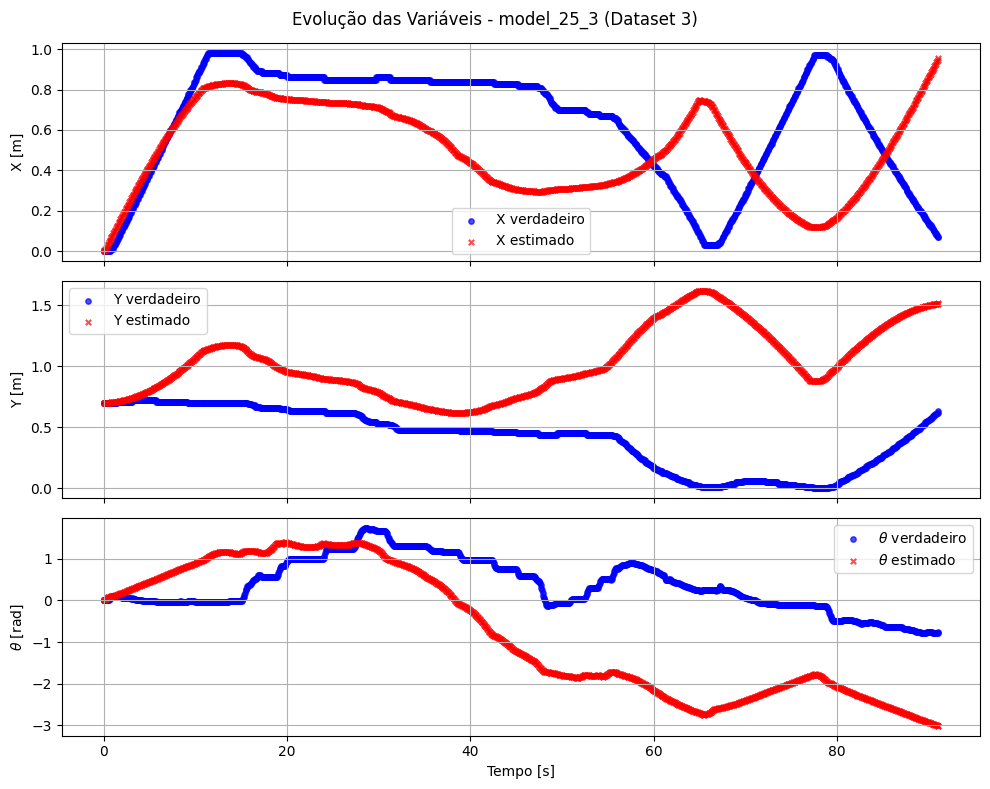



===== Avaliando Dataset 4 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_24_5 =====
R2_X = 0.3284, MSE_X = 0.062049
R2_Y = -0.2101, MSE_Y = 0.089571
R2_Theta = -0.9980, MSE_Theta = 0.659254


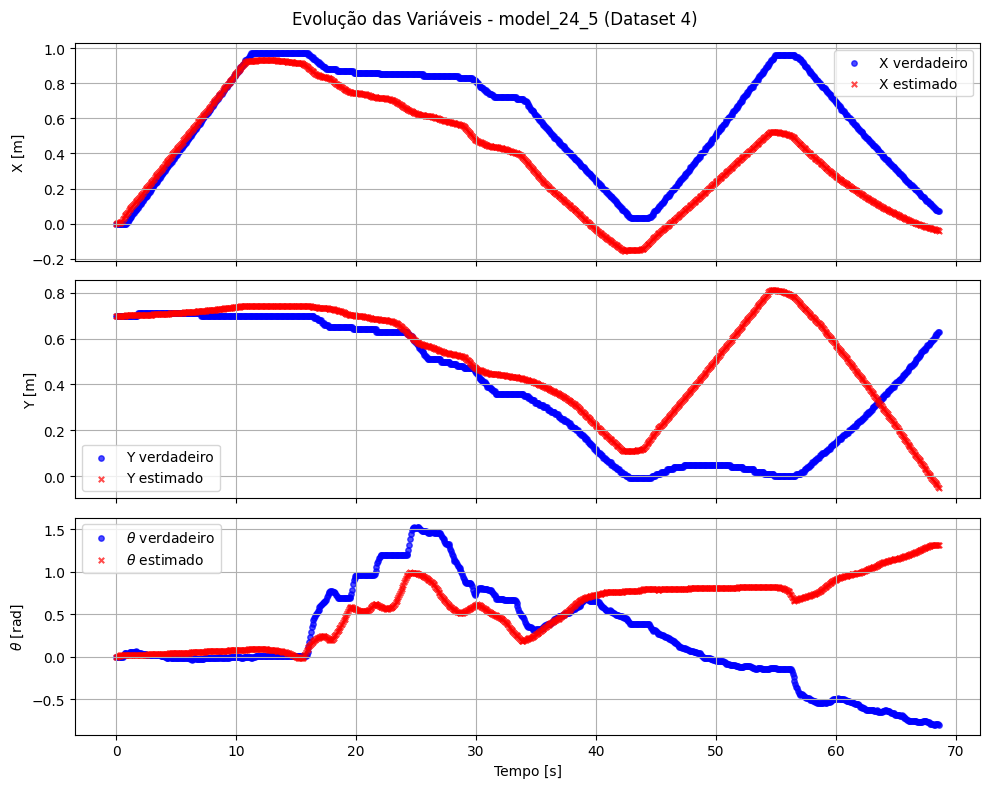

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_12_4 =====
R2_X = -8.3728, MSE_X = 0.865896
R2_Y = -36.2923, MSE_Y = 2.760420
R2_Theta = -24.9886, MSE_Theta = 8.575054


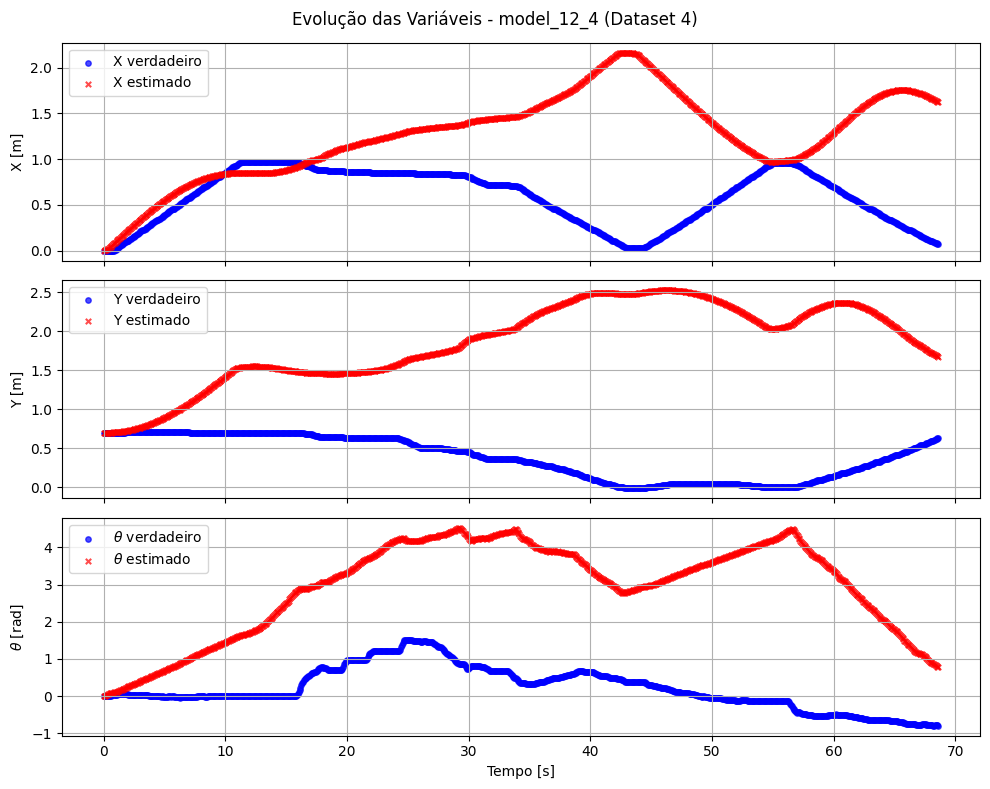

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_22_0 =====
R2_X = -0.7601, MSE_X = 0.162605
R2_Y = -0.4502, MSE_Y = 0.107346
R2_Theta = -553.1426, MSE_Theta = 182.842080


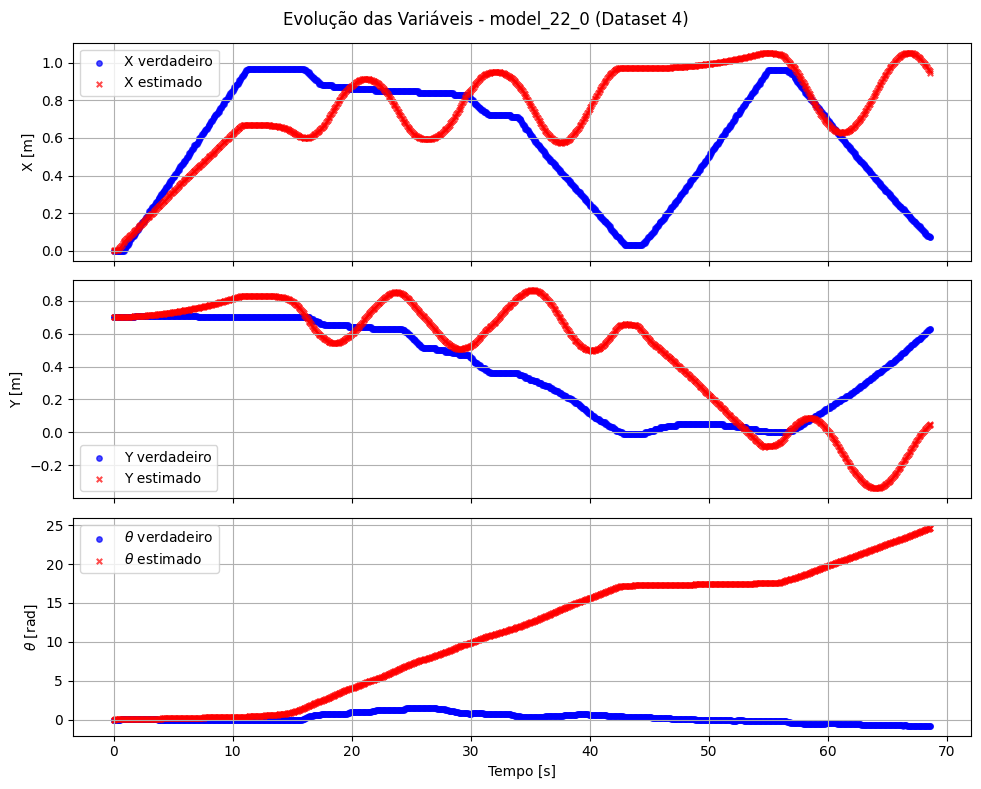

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_25_3 =====
R2_X = 0.8384, MSE_X = 0.014930
R2_Y = -0.3497, MSE_Y = 0.099903
R2_Theta = -1.5268, MSE_Theta = 0.833735


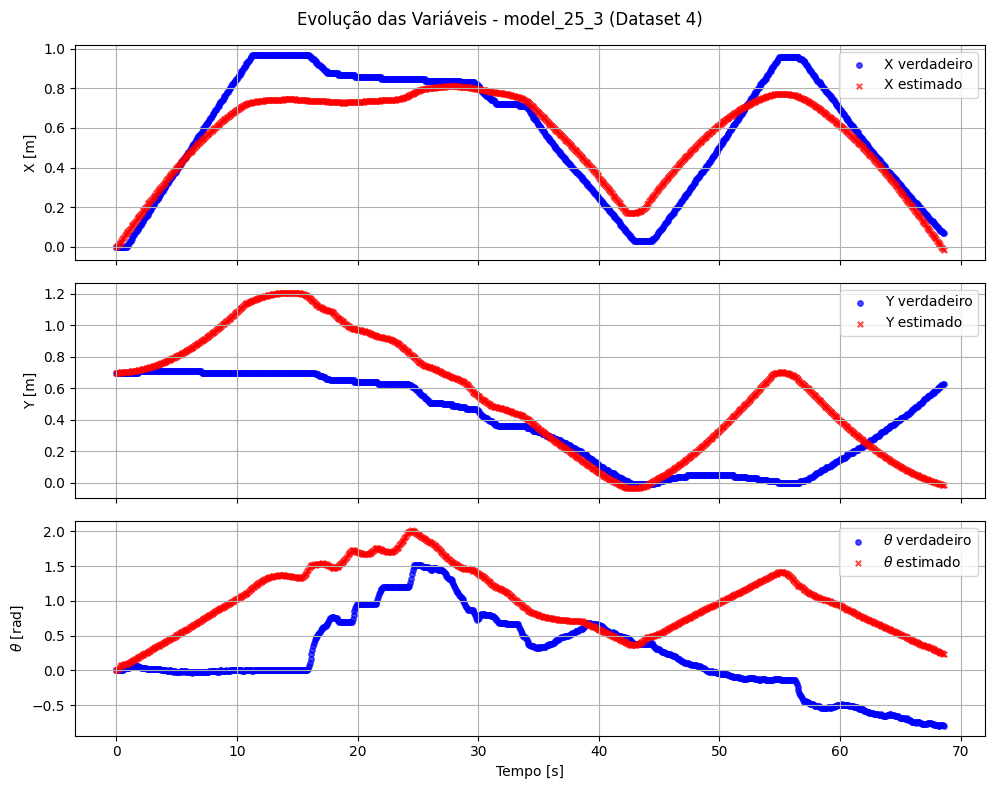

In [19]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    for idx, ModelConf in ModelsConfs.iterrows():
        n = int(ModelConf["Neurons"])
        Name = ModelConf["model"]

        # --- Carrega pesos do modelo ---
        Wf = [np.array(w) for w in ast.literal_eval(ModelConf["Wf"])]

        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh"),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear")
        ])
        model.set_weights(Wf)

        # --- Faz predição ---
        Wd_We_pred = OUT_SCALER.inverse_transform(model.predict(x_test))

        # --- Extrai velocidades previstas ---
        Wd_pred = Wd_We_pred[:, 0]   # ωd (roda direita)
        We_pred = Wd_We_pred[:, 1]   # ωe (roda esquerda)

        # --- Calcula odometria estimada ---
        X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

        # Garante que os tamanhos batem
        min_len = min(len(X_true), len(X_est))
        X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
        X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

        # --- Cálculo das métricas ---
        r2_x = r2_score(X_true, X_est)
        r2_y = r2_score(Y_true, Y_est)
        r2_theta = r2_score(Theta_true, Theta_est)

        mse_x = mean_squared_error(X_true, X_est)
        mse_y = mean_squared_error(Y_true, Y_est)
        mse_theta = mean_squared_error(Theta_true, Theta_est)

        print(f"\n===== {Name} =====")
        print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
        print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
        print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

        # --- Armazena resultados ---
        results.append({
            "Dataset": i + 1,
            "Model": Name,
            "Neurons": n,
            "R2_X": r2_x, "MSE_X": mse_x,
            "R2_Y": r2_y, "MSE_Y": mse_y,
            "R2_Theta": r2_theta, "MSE_Theta": mse_theta
        })

        # --- Gera gráfico ---
        PlotTrajectoryEvolution(
            X_true, Y_true, Theta_true,
            X_est, Y_est, Theta_est,
            f"Evolução das Variáveis - {Name} (Dataset {i+1})"
        )
        
results_df = pd.DataFrame(results)
results_df.to_excel("Odometry.xlsx")


In [20]:
results_df.to_csv("odometry.csv")